In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from cebmf_torch import cEBMF
# Reproducibility
torch.manual_seed(1)

# -------------------------
# 1) Random uniform data
# -------------------------
N = 2000  
P=1000
 

ADD spatial effect

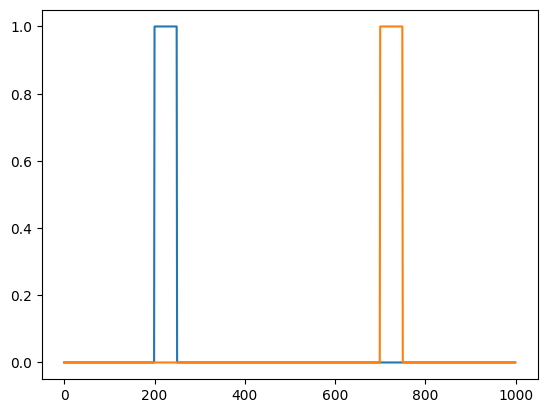

In [2]:
f1= torch.zeros(P)
f1[200:250]=1
f2= torch.zeros(P)
f2[700:750]=1


plt.plot(f1)
plt.plot(f2)

L1=   torch.randint(0, 2, (N,), dtype=torch.float32) 

L2=   torch.randint(0, 2, (N,), dtype=torch.float32) 
F_ATAC= torch.vstack([f1, f2 ] )
L_ATAC= torch.vstack([L1, L2 ] ).T
X_ATAC= L_ATAC @F_ATAC 

<Axes: >

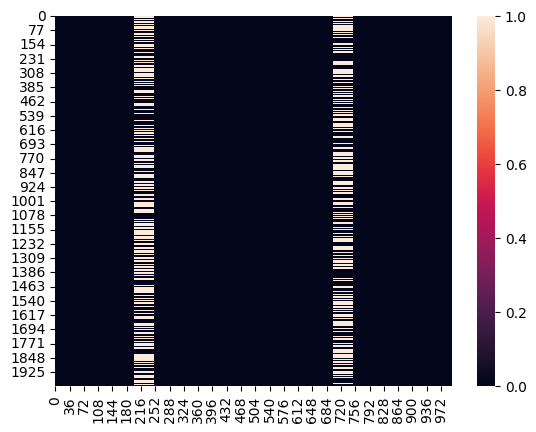

In [3]:
sns.heatmap(X_ATAC)

In [4]:
f1r= torch.zeros(P)
f1r[200:250]=1
f1r[500:250]=1
f1r[700:250]=1

f2r= torch.zeros(P)
 
f2r[500:550]=1
f2r[700:750]=1

f3r= torch.zeros(P)
 
f3r[200:250]=1
f3r[700:750]=1

f4r= torch.zeros(P)
f1r[200:250]=1
f1r[500:250]=1
 

L_RNA= torch.zeros(N, 4)

In [5]:
L_RNA

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [6]:
for i in range (L_RNA.shape[1]):
    if L_ATAC[i,1]==1 and L_ATAC[i,0]==0:
        L_RNA[i,0]=1

    if L_ATAC[i,0]==0 and L_ATAC[i,1]==1:
        L_RNA[i,1]=1

    if L_ATAC[i,0]==1 and L_ATAC[i,1]==1:
        L_RNA[i,2]=1

    if L_ATAC[i,0]==0 and L_ATAC[i,1]==0:
        L_RNA[i,3]=1


In [7]:
torch.sum(L_RNA[:,1])

tensor(1.)

In [8]:
# --- feature patterns (fix empty slices and wrong target) ---
f1r = torch.zeros(P); f1r[200:250] = 1; f1r[500:550] = 1; f1r[700:750] = 1
f2r = torch.zeros(P); f2r[500:550] = 1; f2r[700:750] = 1
f3r = torch.zeros(P); f3r[200:250] = 1; f3r[700:750] = 1
f4r = torch.zeros(P); f4r[200:250] = 1; f4r[500:550] = 1  # <-- was writing into f1r by mistake

# --- build L_RNA from L_ATAC patterns (no Python loop) ---
L_RNA = torch.zeros(N, 4, dtype=torch.float32, device=L_ATAC.device)

mask01 = (L_ATAC[:,0] == 0) & (L_ATAC[:,1] == 1)  # -> col 0
mask10 = (L_ATAC[:,0] == 1) & (L_ATAC[:,1] == 0)  # -> col 1  (FIXED)
mask11 = (L_ATAC[:,0] == 1) & (L_ATAC[:,1] == 1)  # -> col 2
mask00 = (L_ATAC[:,0] == 0) & (L_ATAC[:,1] == 0)  # -> col 3

L_RNA[mask01, 0] = 1
L_RNA[mask10, 1] = 1
L_RNA[mask11, 2] = 1
L_RNA[mask00, 3] = 1

print(L_RNA[:,1].sum())  # should now be equal to mask10.sum()


tensor(494.)


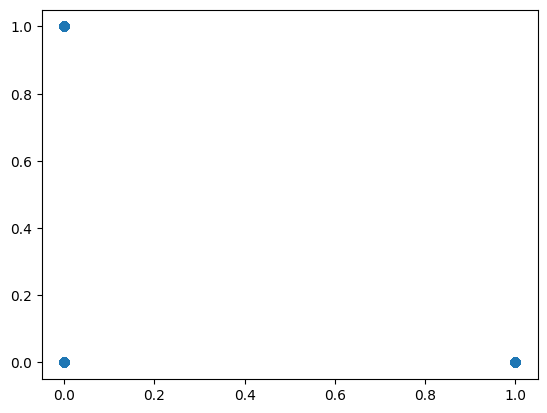

In [9]:
plt.scatter ( L_ATAC[:,1], L_RNA[:,1]) 

<Axes: >

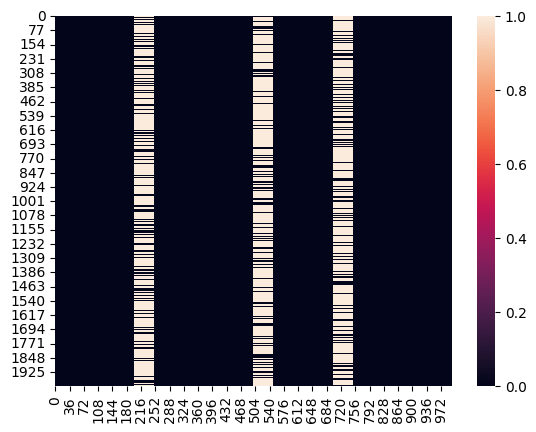

In [10]:
f_RNA =torch.vstack([f1r,f2r,f3r,f4r])

X_RNA= L_RNA @f_RNA

sns.heatmap(X_RNA)

In [11]:

X_obs_RNA= X_RNA+2*torch.randn(N, P)

X_obs_ATAC= X_ATAC+2*torch.randn(N, P)

mycebmf0R=  cEBMF(data=X_obs_RNA ,K=10 ) 
mycebmf0R.initialise_factors()

mycebmf0R.fit(50)


CEBMFResult(L=tensor([[  7.7960,   4.4620,   7.6940,  ...,   0.0000,   0.0000,   0.0000],
        [  4.4322,  10.9450,   6.9178,  ...,   0.0000,   0.0000,   0.0000],
        [  5.0844,  -6.3903,   8.9157,  ...,   0.0000,   0.0000,   0.0000],
        ...,
        [ 14.9818,   1.4614,   1.6695,  ...,   0.0000,   0.0000,   0.0000],
        [  6.0483,  -9.5240,   9.4442,  ...,   0.0000,   0.0000,   0.0000],
        [  4.2317, -10.6181,   7.1766,  ...,   0.0000,   0.0000,   0.0000]]), F=tensor([[-1.3927e-05, -1.6238e-04,  6.8521e-06,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.2258e-05, -3.2461e-04, -8.9194e-07,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 5.4123e-05, -6.0036e-05,  1.4931e-05,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-1.5447e-05, -7.3559e-05, -6.6507e-05,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 4.9013e-05,  7.9297e-05, -6.7564e-05,  ...,  0.0000e+00,
          0.0000e+00,

In [12]:
mycebmf0A=  cEBMF(data=X_obs_ATAC ,K=10 ) 
mycebmf0A.initialise_factors()

mycebmf0A.fit(50)

CEBMFResult(L=tensor([[ 9.4297, -0.4849,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 7.0519, -1.1468,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-2.7881, -0.0894,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 6.4975,  1.6611,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-2.1196, -2.0972,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-1.9667,  0.0141,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]), F=tensor([[-1.0894e-04, -2.1908e-05,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-2.3463e-04,  2.5494e-05,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-2.1096e-04, -3.0767e-04,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-1.3377e-04, -8.6460e-05,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-6.7853e-06,  1.2717e-04,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.3458e-04,

<Axes: >

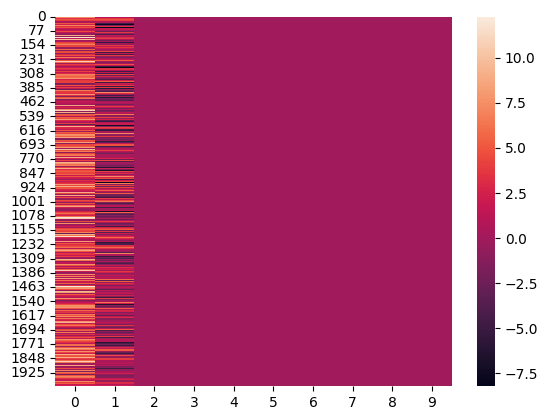

In [13]:
sns.heatmap(mycebmf0A.L)

<Axes: >

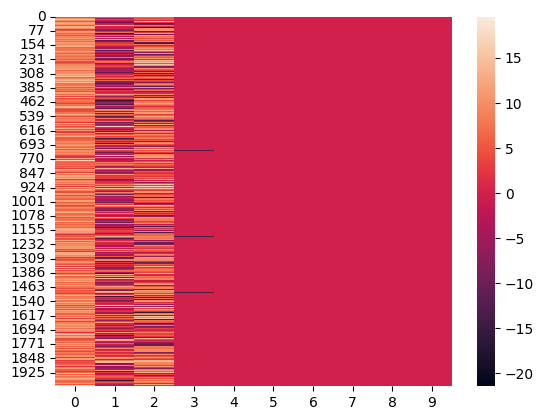

In [14]:

sns.heatmap(mycebmf0R.L)


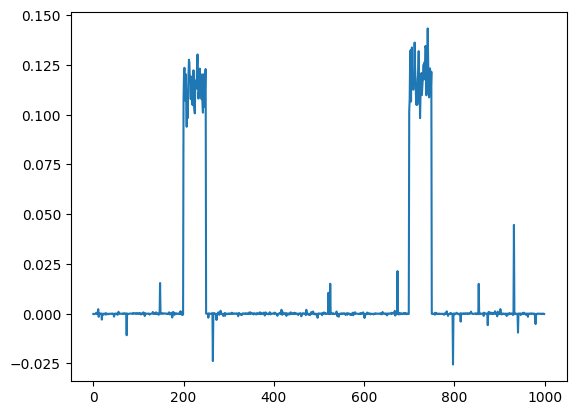

In [15]:
plt.plot(mycebmf0A.F[:,0])

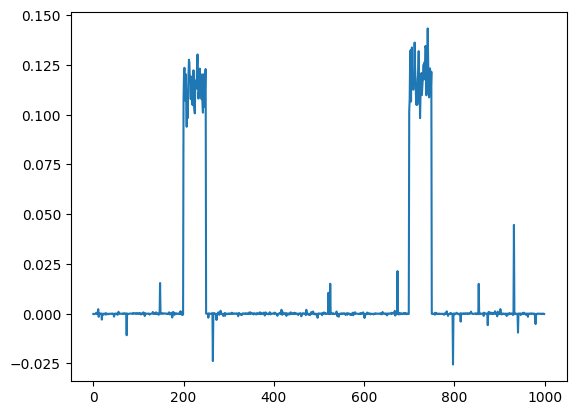

In [16]:
plt.plot(mycebmf0A.F[:,0])

In [17]:
X_initRNA  = mycebmf0A.L
X_initATAC = mycebmf0R.L
p_rna = X_obs_RNA.shape[1]                 # number of columns
y_rna =  torch.arange(1, p_rna + 1)
p_atac = X_obs_ATAC.shape[1]                 # number of columns
y_atac=  torch.arange(1,p_atac  + 1)  # 1 to p inclusive
 

In [19]:





mycebmfR=  cEBMF(data=X_obs_RNA,
                prior_L = "cgb",
                X_l= mycebmf0A.L,
                 prior_F="emdn", 
                  X_f=y_rna,
                   K=10 ,
                  allow_backfitting=False) 
mycebmfR.initialise_factors()

mycebmfR.L=mycebmf0R.L
mycebmfR.F=mycebmf0R.F
mycebmfA=  cEBMF(data=X_obs_ATAC , 
                 prior_L = "cgb",
                X_l= mycebmf0A.L,
                  prior_F="emdn", 
                   X_f=y_rna,
                   K=10,
                  allow_backfitting=False ) 
mycebmfA.initialise_factors()

mycebmfA.L=mycebmf0A.L
mycebmfA.F=mycebmf0A.F

In [20]:

for i in range(10):
    mycebmfR.X_l= mycebmfA.L
    mycebmfR.iter_once()
    mycebmfA.X_l= mycebmfR.L
    mycebmfA.iter_once()

[CGB] Epoch 10/10, Loss=4.4397, mu2=0.162, sigma2=8.636
[EMDN] Epoch 10/10, Loss: 0.5186
[CGB] Epoch 10/10, Loss=2.0443, mu2=0.032, sigma2=0.001
[EMDN] Epoch 10/10, Loss: 4.3129
[CGB] Epoch 10/10, Loss=2.1684, mu2=0.063, sigma2=0.941
[EMDN] Epoch 10/10, Loss: 1.2136
[CGB] Epoch 10/10, Loss=1.9052, mu2=-0.011, sigma2=0.001
[EMDN] Epoch 10/10, Loss: 5.3596
[CGB] Epoch 10/10, Loss=1.6018, mu2=0.000, sigma2=0.001
[EMDN] Epoch 10/10, Loss: 7.5775
[CGB] Epoch 10/10, Loss=1.6007, mu2=0.000, sigma2=0.001
[EMDN] Epoch 10/10, Loss: 7.9298
[CGB] Epoch 10/10, Loss=1.6003, mu2=0.000, sigma2=0.001
[EMDN] Epoch 10/10, Loss: 8.2569
[CGB] Epoch 10/10, Loss=1.6013, mu2=0.000, sigma2=0.001
[EMDN] Epoch 10/10, Loss: 7.6877
[CGB] Epoch 10/10, Loss=1.6021, mu2=0.000, sigma2=0.001
[EMDN] Epoch 10/10, Loss: 7.5050
[CGB] Epoch 10/10, Loss=1.6009, mu2=0.000, sigma2=0.001
[EMDN] Epoch 10/10, Loss: 7.8210
[CGB] Epoch 10/10, Loss=3.7537, mu2=0.151, sigma2=9.035
[EMDN] Epoch 10/10, Loss: 0.5408
[CGB] Epoch 10/10, L

In [21]:
mycebmfA.L

tensor([[ 7.9811e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 6.7913e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-2.9870e-06,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [ 5.3219e+00,  8.3258e-08,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.7748e-06,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.0409e-06,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])

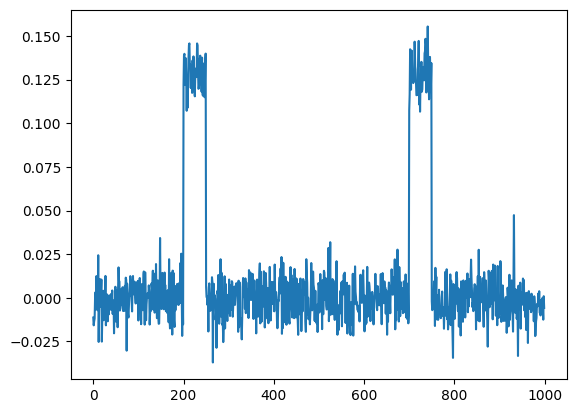

In [22]:
plt.plot(mycebmfA.F[:,0
                    ])

<Axes: >

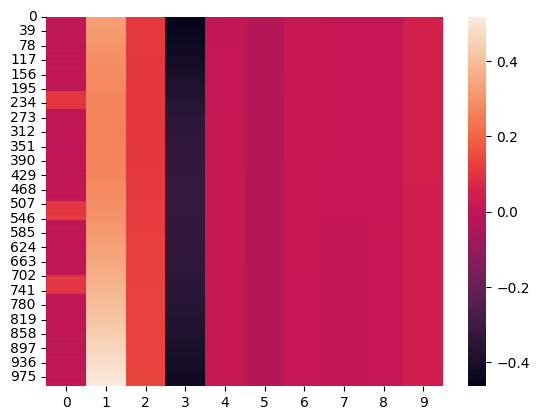

In [23]:
sns.heatmap(mycebmfR.F)